In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import PoissonRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import math


In [ ]:
path = "League Table (2026).xlsx"

base = pd.read_excel(path, sheet_name="Base")
rt   = pd.read_excel(path, sheet_name="teams_attack_rating")

rt = rt[["Teams", "Team Attack Strength", "Defensive Strength"]].dropna(subset=["Teams"]).copy()

#Normalize teams
rt["Teams"] = rt["Teams"].astype(str).str.strip().str.lower()
base["home_team"] = base["home_team"].astype(str).str.strip().str.lower()
base["away_team"] = base["away_team"].astype(str).str.strip().str.lower()

home_rt = rt.rename(columns={
    "Teams": "home_team",
    "Team Attack Strength": "home_attack",
    "Defensive Strength": "home_def"
})
away_rt = rt.rename(columns={
    "Teams": "away_team",
    "Team Attack Strength": "away_attack",
    "Defensive Strength": "away_def"
})

m = (base
    .merge(home_rt, on="home_team", how="left")
    .merge(away_rt, on="away_team", how="left"))

home_rows = pd.DataFrame({
    "team": m["home_team"],
    "opp":  m["away_team"],
    "goals": m["sum home_goals"].astype(int),
    "is_home": 1,
    "log_attack": np.log(m["home_attack"]),
    "log_opp_concede": np.log(m["away_def"]),
})

away_rows = pd.DataFrame({
    "team": m["away_team"],
    "opp":  m["home_team"],
    "goals": m["sum away_goals"].astype(int),
    "is_home": 0,
    "log_attack": np.log(m["away_attack"]),
    "log_opp_concede": np.log(m["home_def"]),
})

team_df = pd.concat([home_rows, away_rows], ignore_index=True)

X = team_df[["is_home", "log_attack", "log_opp_concede"]]
y = team_df["goals"].values

pois = PoissonRegressor(alpha=0.0, max_iter=20000) 
pois.fit(X, y)

print("intercept:", pois.intercept_)
print("coef (is_home, log_attack, log_opp_concede):", pois.coef_)

intercept: 0.9799549078804274
coef (is_home, log_attack, log_opp_concede): [ 0.14804712  0.23962197 -1.00124042]


C:\Users\PC\AppData\Local\Temp\ipykernel_141956\2775990689.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = pd.DataFrame({"pred": pred, "actual": actual, "bin": bins}).groupby("bin")


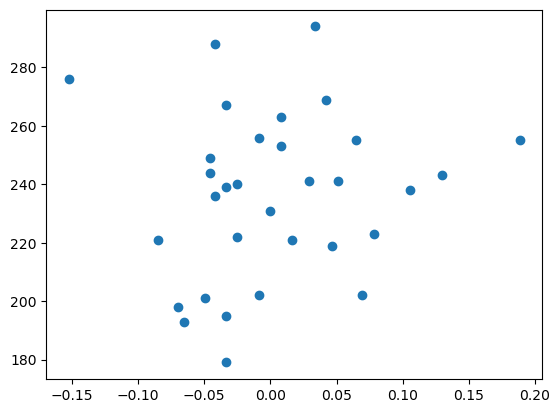

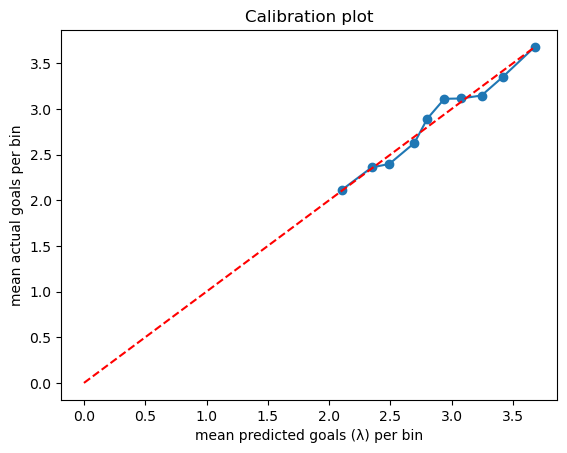

,pred_mean,actual_mean,n
0,2.104630,2.114068,263
1,2.346871,2.358779,262
2,2.490629,2.396947,262
3,2.695998,2.627376,263
4,2.800869,2.893130,262
5,2.940265,3.110266,263
6,3.073413,3.113636,264
7,3.243166,3.146154,260
8,3.418819,3.352273,264
9,3.676735,3.678161,261


In [ ]:
gp = team_df.groupby("team").size()
atk = team_df.groupby("team")["log_attack"].first()

plt.plot(atk.values, team_df.groupby("team")["goals"].sum().values, "o")

pred = pois.predict(X)
actual = team_df["goals"].to_numpy()
bins = pd.qcut(pred, q=10, duplicates="drop")

g = pd.DataFrame({"pred": pred, "actual": actual, "bin": bins}).groupby("bin")
pred_mean = g["pred"].mean()
actual_mean = g["actual"].mean()

plt.figure()
plt.plot(pred_mean, actual_mean, "o-")
mx = max(pred_mean.max(), actual_mean.max())
plt.plot([0, mx], [0, mx], "--", color="red")
plt.xlabel("mean predicted goals (λ) per bin")
plt.ylabel("mean actual goals per bin")
plt.title("Calibration plot")
plt.show()

cal = pd.DataFrame({
    "pred_mean": pred_mean,
    "actual_mean": actual_mean,
    "n": g.size()
}).reset_index()

cal[["pred_mean", "actual_mean", "n"]]